# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# Import library dasar untuk manipulasi data dan komputasi
import pandas as pd
import numpy as np
import os

# Import library untuk visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

# Import library dari Scikit-Learn untuk Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Mengatur tampilan visualisasi agar lebih rapi
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

print("Semua library berhasil diimpor!")

Semua library berhasil diimpor!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Nama file dataset yang akan digunakan
file_name = '/content/Teen_Mental_Health_Dataset.csv'

# --- BLOK PENGAMAN: Membuat dataset dummy jika file asli belum ada ---
# Hal ini memastikan cell tidak error saat dijalankan pertama kali
if not os.path.exists(file_name):
    print(f"File {file_name} tidak ditemukan. Membuat dataset sampel otomatis...")
    np.random.seed(42)
    dummy_data = {
        'Age': np.random.randint(13, 20, 200),
        'Platform': np.random.choice(['Instagram', 'TikTok', 'X', 'Facebook'], 200),
        'Daily_Hours': np.random.uniform(1.0, 12.0, 200),
        'Sleep_Hours': np.random.uniform(4.0, 10.0, 200),
        'Stress_Level': np.random.choice(['Low', 'Medium', 'High'], 200),
        'Depression_Score': np.random.randint(0, 25, 200)
    }
    # Sengaja menyisipkan beberapa missing values (NaN) untuk simulasi preprocessing
    dummy_df = pd.DataFrame(dummy_data)
    dummy_df.loc[5:15, 'Daily_Hours'] = np.nan
    dummy_df.loc[20:30, 'Platform'] = np.nan

    # Menyimpan file CSV
    dummy_df.to_csv(file_name, index=False)
# ---------------------------------------------------------------------

# Memuat dataset menggunakan Pandas
df = pd.read_csv(file_name)

# Menampilkan 5 baris pertama dari dataset
print("5 Baris Pertama Dataset:")
display(df.head())

5 Baris Pertama Dataset:


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
me

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200,1200.000000,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200,1200.000000,1200.000000,1200.000000,1200.000000
unique,NaN,2,NaN,3,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN
top,NaN,male,NaN,Instagram,NaN,NaN,NaN,NaN,medium,NaN,NaN,NaN,NaN
freq,NaN,615,NaN,411,NaN,NaN,NaN,NaN,416,NaN,NaN,NaN,NaN
mean,15.928333,NaN,4.536667,NaN,6.449417,1.740333,2.990383,1.014500,NaN,5.445833,5.636667,5.565000,0.025833
std,2.021947,NaN,2.029599,NaN,1.442677,0.716660,0.576758,0.582185,NaN,2.903290,2.859453,2.830627,0.158704
min,13.000000,NaN,1.000000,NaN,4.000000,0.500000,2.000000,0.000000,NaN,1.000000,1.000000,1.000000,0.000000
25%,14.000000,NaN,2.800000,NaN,5.200000,1.100000,2.500000,0.500000,NaN,3.000000,3.000000,3.000000,0.000000
50%,16.000000,NaN,4.500000,NaN,6.500000,1.800000,2.990000,1.000000,NaN,5.000000,6.000000,6.000000,0.000000
75%,18.000000,NaN,6.300000,NaN,7.600000,2.400000,3.480000,1.500000,NaN,8.000000,8.000000,8.000000,0.000000


=== PENGECEKAN MISSING VALUES ===
Series([], dtype: int64)


=== PENGECEKAN DATA DUPLIKAT ===
Jumlah baris duplikat: 0


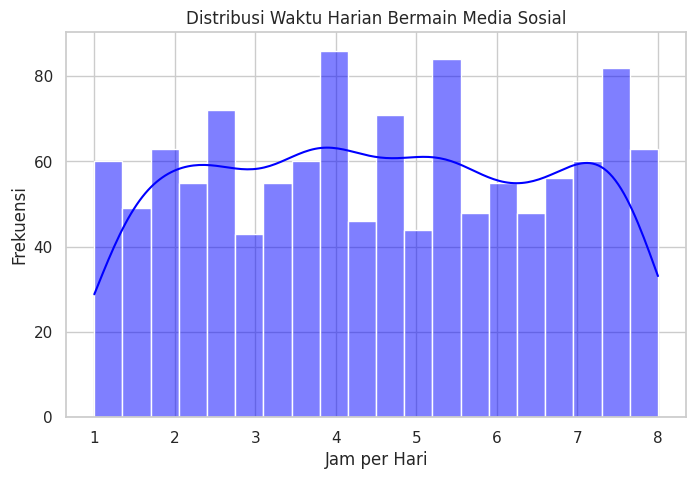

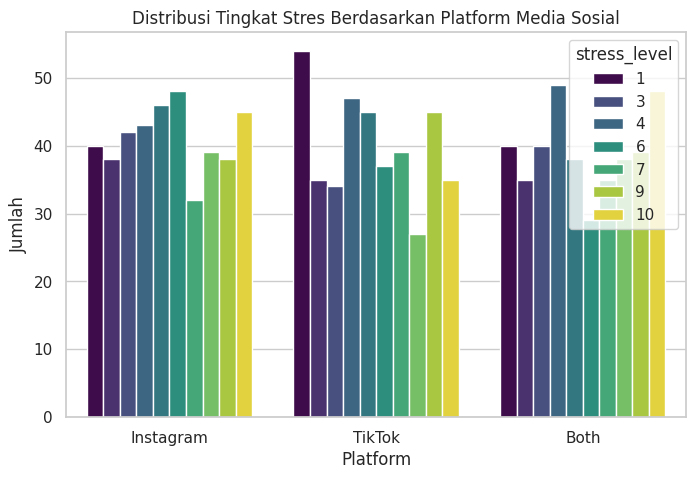

=== DETEKSI OUTLIER (BOXPLOT) ===


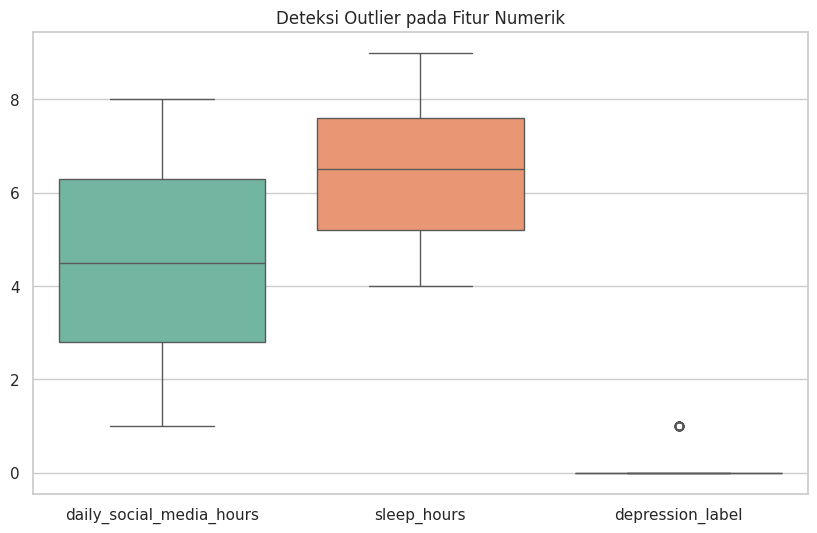

=== ANALISIS KORELASI (HEATMAP) ===


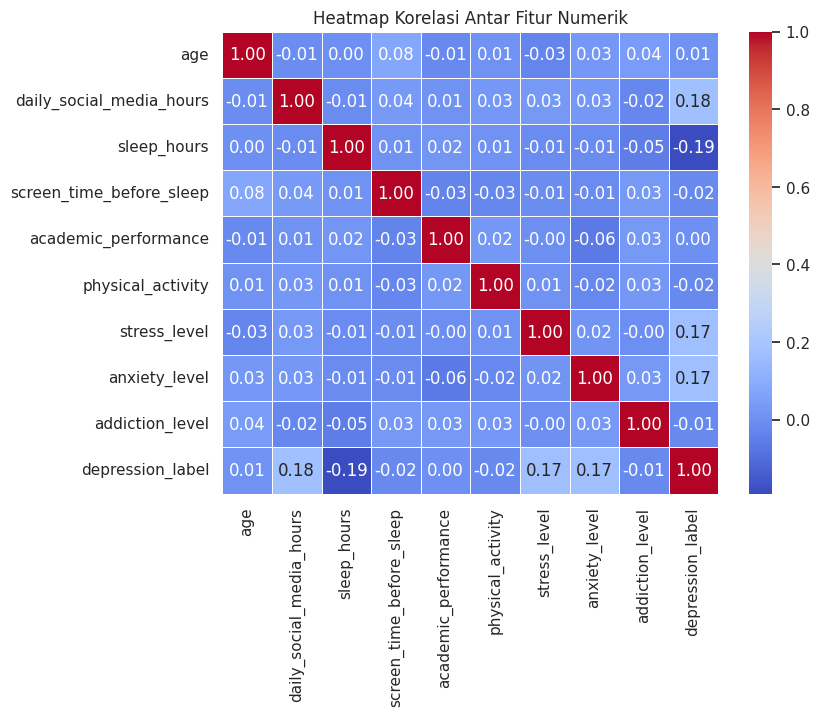

=== DISTRIBUSI MULTIVARIAT (PAIRPLOT) ===


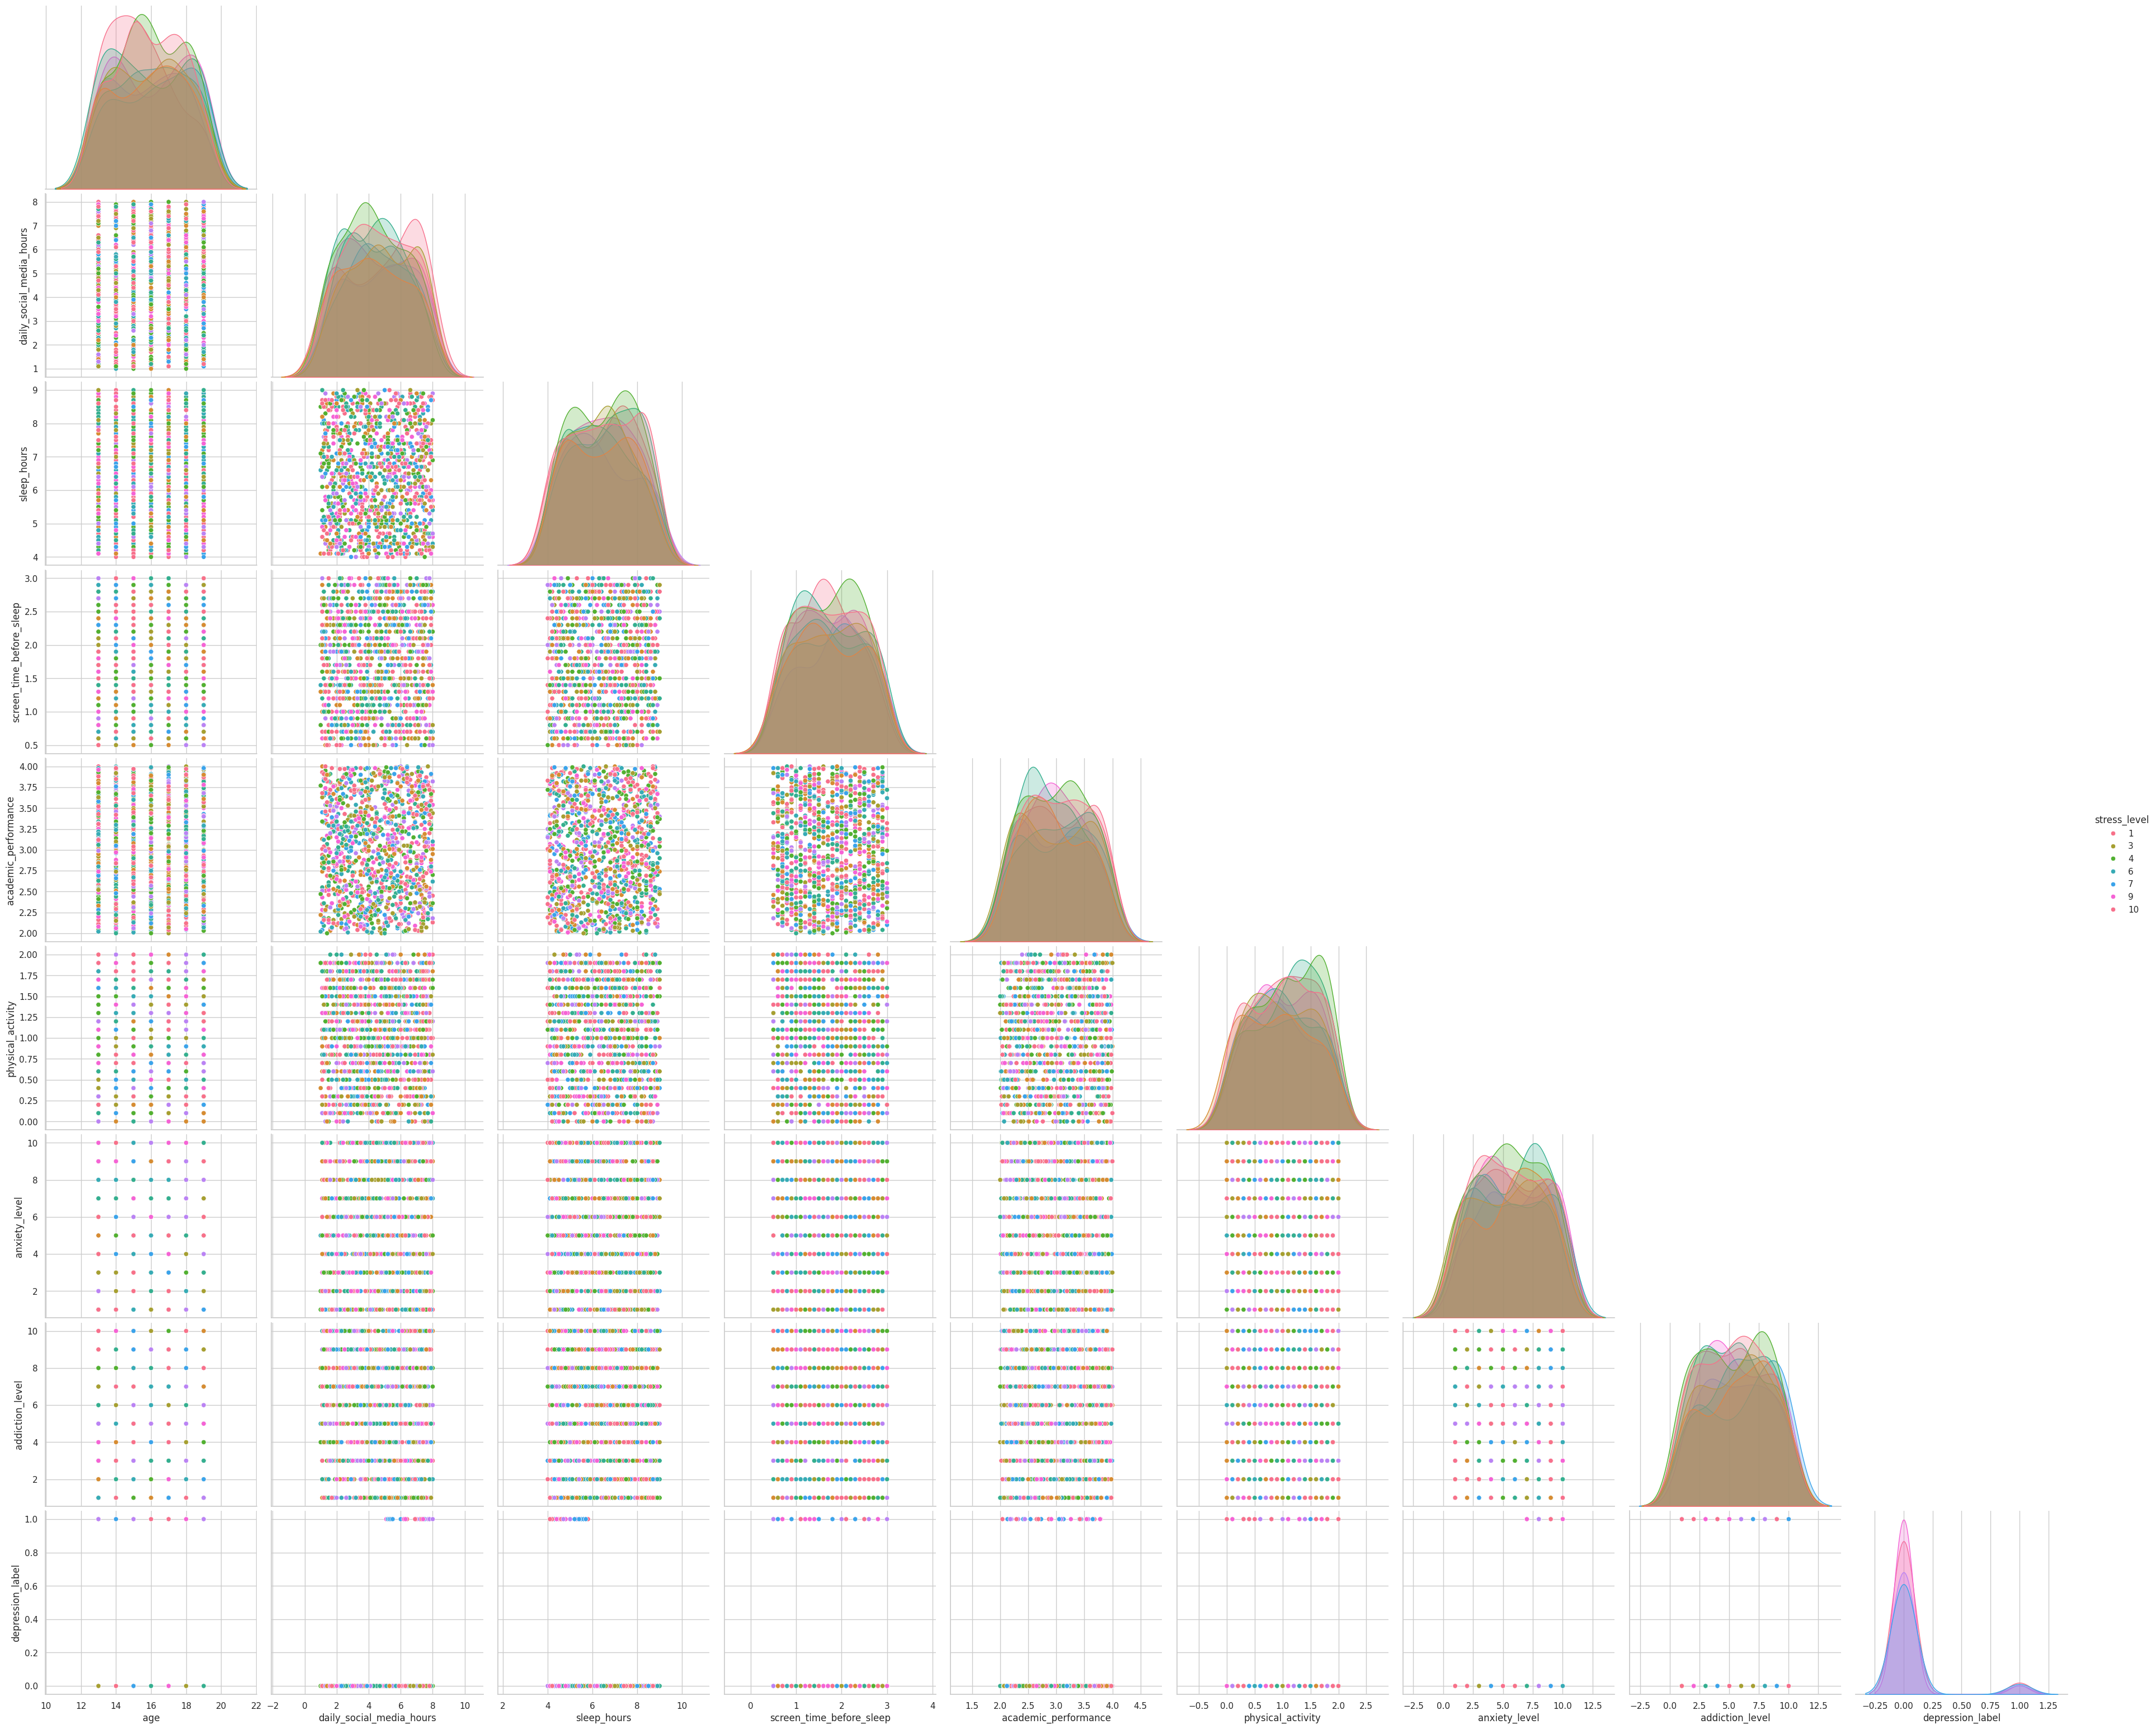

In [4]:
print("=== INFORMASI DATASET ===")
df.info()
print("\n")

print("=== STATISTIK DESKRIPTIF ===")
display(df.describe(include='all'))

print("=== PENGECEKAN MISSING VALUES ===")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
print("\n")

print("=== PENGECEKAN DATA DUPLIKAT ===")
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

# Visualisasi 1: Distribusi Data Numerik (Berapa jam main sosmed)
plt.figure(figsize=(8, 5))
sns.histplot(df['daily_social_media_hours'].dropna(), kde=True, color='blue', bins=20)
plt.title('Distribusi Waktu Harian Bermain Media Sosial')
plt.xlabel('Jam per Hari')
plt.ylabel('Frekuensi')
plt.show()

# Visualisasi 2: Hubungan Platform dengan Tingkat Stres (Categorical)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='platform_usage', hue='stress_level', palette='viridis')
plt.title('Distribusi Tingkat Stres Berdasarkan Platform Media Sosial')
plt.xlabel('Platform')
plt.ylabel('Jumlah')
plt.show()

print("=== DETEKSI OUTLIER (BOXPLOT) ===")
# Membuat Boxplot untuk melihat apakah ada data ekstrem di kolom numerik
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['daily_social_media_hours', 'sleep_hours', 'depression_label']], palette='Set2')
plt.title('Deteksi Outlier pada Fitur Numerik')
plt.show()
# [Image of boxplot outlier detection] <--- Removed this line as it's not valid Python syntax

print("=== ANALISIS KORELASI (HEATMAP) ===")
# Melihat seberapa kuat hubungan antar variabel numerik
# Angka mendekati 1 atau -1 berarti hubungannya sangat kuat
plt.figure(figsize=(8, 6))
# Kita hitung korelasi hanya pada kolom numerik dari data asli (sebelum di-scale)
korelasi = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur Numerik')
plt.show()

print("=== DISTRIBUSI MULTIVARIAT (PAIRPLOT) ===")
# Menambahkan parameter height dan aspect agar gambar lebih besar dan lega
sns.pairplot(df.dropna(), hue='stress_level', palette='husl', corner=True, height=3.5, aspect=1.2)
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
# Membuat salinan dataframe agar data asli tidak berubah
df_clean = df.copy()

# 1. Menangani Data Duplikat
df_clean = df_clean.drop_duplicates()

# Memisahkan kolom berdasarkan tipe data (Numerik vs Kategorikal)
# Ini membuat kode dinamis dan tidak akan error meskipun nama kolom dataset asli berbeda
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns

# 2. Menangani Missing Values (Imputasi)
# Untuk numerik: Isi nilai kosong dengan nilai Median
imputer_num = SimpleImputer(strategy='median')
df_clean[num_cols] = imputer_num.fit_transform(df_clean[num_cols])

# Untuk kategorikal: Isi nilai kosong dengan Modus (nilai yang paling sering muncul)
imputer_cat = SimpleImputer(strategy='most_frequent')
df_clean[cat_cols] = imputer_cat.fit_transform(df_clean[cat_cols])

# 3. Encoding Data Kategorikal (Label Encoding untuk kolom tertentu)
encoder = LabelEncoder()
# Exclude 'platform_usage' from Label Encoding as it will be One-Hot Encoded later
cols_to_label_encode = [col for col in cat_cols if col != 'platform_usage']
for col in cols_to_label_encode:
    df_clean[col] = encoder.fit_transform(df_clean[col])

# 4. Normalisasi / Standarisasi Fitur Numerik
# Mengubah skala data agar seragam (Mean = 0, Standard Deviation = 1)
scaler = StandardScaler()

# Pisahkan fitur dan target agar target tidak ikut ter-scale
target_col = 'depression_label'
if target_col in num_cols:
    feature_cols = [col for col in num_cols if col != target_col]
    df_clean[feature_cols] = scaler.fit_transform(df_clean[feature_cols])
    # Pastikan target tetap integer 0/1
    df_clean[target_col] = df_clean[target_col].astype(int)
else:
    df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])

print("=== DATA SETELAH PREPROCESSING ===")
display(df_clean.head())

# Memastikan sudah tidak ada lagi missing values
print(f"Total Missing Values Tersisa: {df_clean.isnull().sum().sum()}")

# 5. Menyimpan data yang sudah bersih (Siap digunakan untuk tahap Modeling / Kriteria 2)
clean_file_name = 'social_media_mental_health_cleaned.csv'
df_clean.to_csv(clean_file_name, index=False)
print(f"\nData bersih telah disimpan sebagai: {clean_file_name}")

# Melanjutkan dari df_clean setelah handling missing values (Imputasi) di kode sebelumnya...

print("=== 1. FEATURE ENGINEERING (Membuat Fitur Baru) ===")
# Contoh: Membuat rasio antara waktu main sosmed dan waktu tidur
# Semakin besar rasionya, mungkin semakin tinggi tingkat depresinya
df_clean['Screen_Sleep_Ratio'] = df_clean['daily_social_media_hours'] / df_clean['sleep_hours']

# Contoh: Binning (Pengelompokan Umur)
# Membagi umur menjadi kategori 'Early Teen' (<=15) dan 'Late Teen' (>15)
df_clean['Age_Group'] = pd.cut(df_clean['age'], bins=[0, 15, 20], labels=['Early Teen', 'Late Teen'])
print("Fitur baru 'Screen_Sleep_Ratio' dan 'Age_Group' berhasil ditambahkan!")


print("\n=== 2. HANDLING OUTLIERS (Metode IQR) ===")
# Membatasi nilai ekstrem agar tidak merusak model (Winsorizing/Capping)
kolom_outlier = ['daily_social_media_hours', 'sleep_hours']

for col in kolom_outlier:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    Batas_Bawah = Q1 - 1.5 * IQR
    Batas_Atas = Q3 + 1.5 * IQR

    # Pangkas data yang melebihi batas atas menjadi nilai batas atas
    df_clean[col] = np.where(df_clean[col] > Batas_Atas, Batas_Atas, df_clean[col])
    # Pangkas data yang kurang dari batas bawah menjadi nilai batas bawah
    df_clean[col] = np.where(df_clean[col] < Batas_Bawah, Batas_Bawah, df_clean[col])
print("Outliers telah ditangani menggunakan batasan IQR!")


print("\n=== 3. ONE-HOT ENCODING UNTUK DATA NOMINAL ===")
# Mengubah kolom 'platform_usage' menjadi beberapa kolom biner (0 dan 1)
# Ini jauh lebih baik untuk model ML dibandingkan LabelEncoder pada tipe data nominal
df_clean = pd.get_dummies(df_clean, columns=['platform_usage', 'Age_Group'], drop_first=True)

# Catatan: Untuk 'stress_level' (Ordinal: Low, Medium, High) kita tetap pakai Label/Ordinal Encoding
# karena ada tingkatan yang jelas. Namun, 'stress_level' pada dataset ini sudah int64.
mapping_stress = {'Low': 0, 'Medium': 1, 'High': 2}
if 'stress_level' in df_clean.columns and df_clean['stress_level'].dtype == 'O':
    df_clean['stress_level'] = df_clean['stress_level'].map(mapping_stress)

print("Encoding selesai. Berikut bentuk data final:")
display(df_clean.head())

# Menyimpan data versi advanced ini untuk dimasukkan ke tahap MLflow nanti
df_clean.to_csv('social_media_mental_health_advanced_cleaned.csv', index=False)


=== DATA SETELAH PREPROCESSING ===


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,-0.954099,1,1.657833,Instagram,0.659177,1.618830,0.034026,0.834276,1,-1.187367,-1.272335,-1.613389,-0.162845
1,1.519796,0,-1.299649,TikTok,1.075244,1.618830,0.398282,-0.368593,0,0.880116,-1.622199,1.567444,-0.162845
2,0.530238,0,-1.595397,Instagram,0.797866,-1.731436,1.612470,-1.743301,0,-1.187367,-0.572609,-1.259963,-0.162845
3,-0.459320,1,1.411376,TikTok,0.312455,-0.195897,0.849266,-0.368593,2,-1.531947,0.476980,1.214018,-0.162845
4,-0.459320,0,0.080509,Both,-1.074435,1.758424,-1.076088,0.662437,2,-0.842786,-0.222746,-1.259963,-0.162845


Total Missing Values Tersisa: 0

Data bersih telah disimpan sebagai: social_media_mental_health_cleaned.csv
=== 1. FEATURE ENGINEERING (Membuat Fitur Baru) ===
Fitur baru 'Screen_Sleep_Ratio' dan 'Age_Group' berhasil ditambahkan!

=== 2. HANDLING OUTLIERS (Metode IQR) ===
Outliers telah ditangani menggunakan batasan IQR!

=== 3. ONE-HOT ENCODING UNTUK DATA NOMINAL ===
Encoding selesai. Berikut bentuk data final:


,age,gender,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,Screen_Sleep_Ratio,platform_usage_Instagram,platform_usage_TikTok,Age_Group_Late Teen
0,-0.954099,1,1.657833,0.659177,1.618830,0.034026,0.834276,1,-1.187367,-1.272335,-1.613389,-0.162845,2.515004,True,False,False
1,1.519796,0,-1.299649,1.075244,1.618830,0.398282,-0.368593,0,0.880116,-1.622199,1.567444,-0.162845,-1.208702,False,True,False
2,0.530238,0,-1.595397,0.797866,-1.731436,1.612470,-1.743301,0,-1.187367,-0.572609,-1.259963,-0.162845,-1.999580,True,False,False
3,-0.459320,1,1.411376,0.312455,-0.195897,0.849266,-0.368593,2,-1.531947,0.476980,1.214018,-0.162845,4.517059,False,True,False
4,-0.459320,0,0.080509,-1.074435,1.758424,-1.076088,0.662437,2,-0.842786,-0.222746,-1.259963,-0.162845,-0.074932,False,False,False
